In [5]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score
from sklearn.preprocessing import StandardScaler
from utils import custom_score
from pathlib import Path
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint


In [2]:
data_dir = Path('../data')
X = pd.read_csv(data_dir / 'x_train.txt', sep=' ')
y = pd.read_csv(data_dir / 'y_train.txt', sep=' ').values.ravel()

feature_dir = Path("../feature_selection/selected_features.txt")
with open(feature_dir, "r") as f:
    content = f.read()
selected_features = [x.strip().strip("'").strip('"') for x in content.split(",")]

X = X[selected_features]

In [3]:
data_dir = Path('../data')
X = pd.read_csv(data_dir / 'x_train.txt', sep=' ')
y = pd.read_csv(data_dir / 'y_train.txt', sep=' ').values.ravel()

feature_dir = Path("../feature_selection/selected_features.txt")
with open(feature_dir, "r") as f:
    content = f.read()
selected_features = [x.strip().strip("'").strip('"') for x in content.split(",")]

X = X[selected_features]
# ── Helper: evaluate one (feature subset, hyperparams) config via CV ──────────
def evaluate_config(X, y, features, params, k=5, max_contacts=1000):
    """
    Returns mean project score across k folds.
    features: which columns of X to use
    params: dict of random forest hyperparameters
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = []
    n_var = len(features)

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[features].iloc[train_idx], X[features].iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        model = RandomForestClassifier(**params, random_state=42)
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_val)[:, 1]
        # tak z ciekawosci
        print(f"{accuracy_score(y_val, probs>1/3)}")

        # Decision rule: target customers above threshold, cap at proportional max_contacts
        # (scaled to fold size, since each fold is ~20% of training data)
        fold_cap = int(max_contacts * len(val_idx) / len(y))
        threshold = 1/3  # expected-value break-even: 10p - 5(1-p) > 0
        
        # Take customers with p > threshold, then cap at fold_cap
        candidates = np.where(probs > threshold)[0]
        if len(candidates) > fold_cap:
            top = candidates[np.argsort(-probs[candidates])[:fold_cap]]
        else:
            top = candidates

        y_pred = np.zeros_like(y_val)
        y_pred[top] = 1
        scores.append(custom_score(y_val, y_pred, n_var))

    return np.mean(scores)

# ── Hyperparameter grid  ──────────────────────────────────
param_grid = [
    {"n_estimators": 200, "n_jobs": -1},
    {"n_estimators": 500, "n_jobs": -1},
    {"n_estimators": 700, "n_jobs": -1},
]

# ── Forward selection driven by project score ─────────────────────────────────
n_features = X.shape[1]
selected = ['V11', 'V176', 'V191', 'V255', 'V309']
remaining = list(set(selected_features) - set(selected))
best_score = -np.inf
best_params = None
history = []

while remaining:
    fold_best_score = -np.inf
    fold_best_feat = None
    fold_best_params = None

    for feat in remaining:
        trial_subset = selected + [feat]
        for params in param_grid:
            score = evaluate_config(X, y, trial_subset, params)
            if score > fold_best_score:
                fold_best_score = score
                fold_best_feat = feat
                fold_best_params = params

    # Stop if adding any feature hurts (the −200 penalty isn't paid off)
    if fold_best_score <= best_score:
        print(f"\nNo feature improves score. Stopping.")
        break

    selected.append(fold_best_feat)
    remaining.remove(fold_best_feat)
    best_score = fold_best_score
    best_params = fold_best_params
    history.append((len(selected), fold_best_feat, fold_best_score, fold_best_params))
    print(f"Step {len(selected)}: added feat {fold_best_feat} | "
          f"score = {fold_best_score} | params = {fold_best_params}")

print(f"\n── Final ──")
print(f"Selected {len(selected)} features: {selected}")
print(f"Best params: {best_params}")
print(f"CV score:    {best_score}")

0.557
0.537
0.549


KeyboardInterrupt: 

In [6]:
# do xgb trzeba ustawic wiecej seedow
SEED = 3
# Python randomness
random.seed(SEED)
# NumPy randomness
np.random.seed(SEED)
keep = ['V11', 'V176', 'V191', 'V255', 'V309']
X = X[keep]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

xgb = XGBClassifier(n_estimators=500, learning_rate=0.1, objective='binary:logistic',random_state=SEED, seed=SEED)
xgb.fit(X_train, y_train)
pred = xgb.predict_proba(X_test)
print(accuracy_score(y_test, pred[:,1]>1/3))
print(custom_score(y_test, pred[:,1]>1/3, X_train.shape[1]))

0.57
1240


# models comparison

In [7]:
def sweep_threshold_and_k(thresh_probs, y_thresh, thresholds_grid, k_grid, n_vars):
    """
    Przeszukuje siatkę progów i limitów K, zwracając kombinację dającą najwyższy custom_score.
    """
    best_thr = 1/3
    best_k = 150
    best_score = -np.inf
    thresholds = np.linspace(0.05, 0.65, 80)
    k_contacts_grid = np.arange(50, 801, 20)
    
    for t in thresholds:
        for k_cap in k_contacts_grid:
            # Wybieramy indeksy spełniające próg prawdopodobieństwa
            candidates = np.where(thresh_probs > t)[0]
            
            # Ograniczamy liczbę kontaktów do k_cap
            if len(candidates) > k_cap:
                top_idx = candidates[np.argsort(-thresh_probs[candidates])[:k_cap]]
            else:
                top_idx = candidates
            
            #  wektor predykcji
            preds = np.zeros_like(y_thresh)
            preds[top_idx] = 1
            
            score = custom_score(y_thresh, preds, n_vars)
            
            if score > best_score:
                best_score = score
                best_thr = t
                best_k = k_cap
                
    return best_thr, best_k, best_score


def apply_threshold(test_probs, threshold, max_k):
    """
    Aplikuje wyznaczony próg oraz limit kontaktów K na zbiorze testowym.
    """
    candidates = np.where(test_probs > threshold)[0]
    
    if len(candidates) > max_k:
        top_idx = candidates[np.argsort(-test_probs[candidates])[:max_k]]
    else:
        top_idx = candidates
        
    preds = np.zeros_like(test_probs, dtype=int)
    preds[top_idx] = 1
    return preds

In [8]:
models_dict = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=SEED, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, 
        verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1
    ),
    'SVM_RBF': SVC(
        kernel='rbf', C=1.0, gamma='scale', 
        probability=True, random_state=SEED 
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0,             
        l1_ratio = 0,
        solver='lbfgs',    
        max_iter=1000,       
        random_state=SEED
    ),
    'LogisticRegression_L1_Standard': LogisticRegression(
        C=1.0,              
        l1_ratio = 1.0,     #lasso
        solver='saga',       
        max_iter=5000,     
        random_state=SEED
    ),
    'LogisticRegression_L1_Strong': LogisticRegression(
        C=0.1,              
        l1_ratio = 1.0,   
        solver='saga',       
        max_iter=5000,       
        random_state=SEED
    )
}

In [9]:

N_VARS = X.shape[1] 
summary_results = []
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for model_name, model_obj in models_dict.items():
    print(f"=== Rozpoczynam walidację dla modelu: {model_name} ===")
    
    # Listy na metryki z poszczególnych foldów dla danego modelu
    fold_scores = []
    fold_accuracies = []
    fold_precisions = []
    fold_thresholds = []
    fold_ks = []
    
    for fold_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_skf.split(X, y)):
        
        X_outer_train = X.iloc[outer_train_idx]
        y_outer_train = y[outer_train_idx]
        X_outer_test  = X.iloc[outer_test_idx]
        y_outer_test  = y[outer_test_idx]
        
        # split for training the model, and for finding threshold
        X_pure_tr, X_thresh, y_pure_tr, y_thresh = train_test_split(
            X_outer_train, y_outer_train,
            test_size=0.20, stratify=y_outer_train, random_state=SEED
        )
        
        scaler = StandardScaler()
        scaler.set_output(transform="pandas")
        X_pure_tr_sc   = scaler.fit_transform(X_pure_tr)
        X_thresh_sc    = scaler.transform(X_thresh)
        X_outer_test_sc = scaler.transform(X_outer_test)
        
        # cloning the model, to make sure they are training from scratch
        fold_model = clone(model_obj)
        fold_model.fit(X_pure_tr_sc, y_pure_tr)
        
        # optimal threshold
        thresh_probs = fold_model.predict_proba(X_thresh_sc)[:, 1]
        best_thr, best_k, _ = sweep_threshold_and_k(
            thresh_probs, y_thresh, thresh_probs, y_thresh, N_VARS
        )
        
        # score on outer_test - scale K to test size
        scale = len(y_outer_test) / len(y_thresh)
        test_k = int(best_k * scale)
        
        # prediction on outer test with the found threshold and K
        test_probs = fold_model.predict_proba(X_outer_test_sc)[:, 1]
        y_pred = apply_threshold(test_probs, best_thr, max_k=test_k)
        
        score = custom_score(y_outer_test, y_pred, N_VARS)
        acc   = accuracy_score(y_outer_test, y_pred)
        # zero_division=0 secures for situations, when model for high threshold might predict no positives
        prec  = precision_score(y_outer_test, y_pred, zero_division=0)
        
        fold_scores.append(score)
        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_thresholds.append(best_thr)
        fold_ks.append(best_k)
        
        #print(f"  Fold {fold_idx+1}: Score={score:.1f} | Acc={acc:.3f} | Prec={prec:.3f} | thr={best_thr:.3f} | K={best_k}")
    
    # Obliczanie średnich i odchyleń standardowych dla modelu po 5 foldach
    summary_results.append({
        'Model': model_name,
        'Mean Custom Score': np.mean(fold_scores),
        'Std Custom Score': np.std(fold_scores),
        'Mean Accuracy': np.mean(fold_accuracies),
        'Mean Precision': np.mean(fold_precisions),
        'Mean Threshold': np.mean(fold_thresholds),
        'Mean K': np.mean(fold_ks)
    })
    print(f"=== Zakończono dla {model_name}. Mean Score: {np.mean(fold_scores):.1f} ===\n")

df_summary = pd.DataFrame(summary_results)
# sorting by custom score
df_summary = df_summary.sort_values(by='Mean Custom Score', ascending=False).reset_index(drop=True)

print(df_summary.to_string(index=False))

=== Rozpoczynam walidację dla modelu: XGBoost ===
=== Zakończono dla XGBoost. Mean Score: 1465.0 ===

=== Rozpoczynam walidację dla modelu: LightGBM ===


KeyboardInterrupt: 

# 4 methods 

In [18]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

data_dir = Path('../data')
X_all = pd.read_csv(data_dir / 'x_train.txt', sep=' ')
y_all = pd.read_csv(data_dir / 'y_train.txt', sep=' ').values.ravel()

# Te same 5 zmiennych co w demo
keep = ['V11', 'V176', 'V191', 'V255', 'V309']
X_all = X_all[keep]
#selected_features = [x.strip().strip("'").strip('"') for x in content.split(",")]
#X_all = X_all[selected_features]
# Staly podzial: 60% train | 20% calibration/threshold | 20% test
# -- train: trening modelu
# -- val:   sweep progu (ODDZIELNY od treningu -- inaczej data leakage)
# -- test:  finalna ocena Score (dotykamy tylko raz)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=SEED)
# -> 60% / 20% / 20%

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

N_VARS      = len(keep)
MAX_CONTACT = 750

def apply_threshold(probs, threshold, max_k=MAX_CONTACT):
    """Zwraca binary vector: top-max_k sposrod tych z prob > threshold."""
    candidates = np.where(probs > threshold)[0]
    if len(candidates) > max_k:
        top = candidates[np.argsort(-probs[candidates])[:max_k]]
    else:
        top = candidates
    y_pred = np.zeros(len(probs), dtype=int)
    y_pred[top] = 1
    return y_pred

results = {}   # zbieramy wyniki wszystkich metod
print("Setup gotowy.")
print(f"Train: {X_train_sc.shape}, Val: {X_val_sc.shape}, Test: {X_test_sc.shape}")
print(f"Positive rate -- train: {y_train.mean():.3f}, val: {y_val.mean():.3f}, test: {y_test.mean():.3f}")


Setup gotowy.
Train: (3000, 5), Val: (1000, 5), Test: (1000, 5)
Positive rate -- train: 0.498, val: 0.497, test: 0.498


In [19]:
# ── A) Threshold Moving ──────────────────────────────────────────────────────

xgb_a = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=SEED,
    verbosity=0,
)
xgb_a.fit(X_train_sc, y_train)

# Sweep progu na val (NIE na train)
probs_val_a = xgb_a.predict_proba(X_val_sc)[:, 1]
thresholds  = np.linspace(0.05, 0.90, 200)
best_thr_a, best_val_score_a = 0.333, -np.inf

for thr in thresholds:
    y_pred_val = apply_threshold(probs_val_a, thr)
    s = custom_score(y_val, y_pred_val, N_VARS)
    if s > best_val_score_a:
        best_val_score_a = s
        best_thr_a = thr

# Finalny Score na tescie
probs_test_a = xgb_a.predict_proba(X_test_sc)[:, 1]
y_pred_test_a = apply_threshold(probs_test_a, best_thr_a)
score_test_a = custom_score(y_test, y_pred_test_a, N_VARS)

tp_a = int(np.sum((y_pred_test_a == 1) & (y_test == 1)))
fp_a = int(np.sum((y_pred_test_a == 1) & (y_test == 0)))
contacted_a = int(y_pred_test_a.sum())

print(f"[A] Optymalny prog (val):  {best_thr_a:.3f}")
print(f"[A] Val Score:             {best_val_score_a:.1f}")
print(f"[A] Test Score:            {score_test_a:.1f}")
print(f"[A] Kontaktow: {contacted_a}  |  TP: {tp_a}  |  FP: {fp_a}")

results['A_threshold_moving'] = {
    'val_score': best_val_score_a,
    'test_score': score_test_a,
    'threshold': best_thr_a,
    'contacted': contacted_a,
    'TP': tp_a, 'FP': fp_a,
}


[A] Optymalny prog (val):  0.362
[A] Val Score:             1260.0
[A] Test Score:            1205.0
[A] Kontaktow: 690  |  TP: 377  |  FP: 313


In [20]:
# ── B) Class Weighting ───────────────────────────────────────────────────────

# scale_pos_weight = C(FP) / C(TP) = 5 / 10 = 0.5
# XGBoost mnozy gradient dla pozytywnych przykladow przez ten wspolczynnik
SCALE_POS = 5.0 / 10.0   # = 0.5

xgb_b = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    scale_pos_weight=SCALE_POS,
    eval_metric='auc',
    random_state=SEED,
    verbosity=0,
)
xgb_b.fit(X_train_sc, y_train)

# Sweep progu na val
probs_val_b = xgb_b.predict_proba(X_val_sc)[:, 1]
best_thr_b, best_val_score_b = 0.333, -np.inf

for thr in thresholds:
    y_pred_val = apply_threshold(probs_val_b, thr)
    s = custom_score(y_val, y_pred_val, N_VARS)
    if s > best_val_score_b:
        best_val_score_b = s
        best_thr_b = thr

# Finalny Score na tescie
probs_test_b = xgb_b.predict_proba(X_test_sc)[:, 1]
y_pred_test_b = apply_threshold(probs_test_b, best_thr_b)
score_test_b = custom_score(y_test, y_pred_test_b, N_VARS)

tp_b = int(np.sum((y_pred_test_b == 1) & (y_test == 1)))
fp_b = int(np.sum((y_pred_test_b == 1) & (y_test == 0)))
contacted_b = int(y_pred_test_b.sum())

print(f"[B] scale_pos_weight:      {SCALE_POS}")
print(f"[B] Optymalny prog (val):  {best_thr_b:.3f}")
print(f"[B] Val Score:             {best_val_score_b:.1f}")
print(f"[B] Test Score:            {score_test_b:.1f}")
print(f"[B] Kontaktow: {contacted_b}  |  TP: {tp_b}  |  FP: {fp_b}")

results['B_class_weighting'] = {
    'val_score': best_val_score_b,
    'test_score': score_test_b,
    'threshold': best_thr_b,
    'contacted': contacted_b,
    'TP': tp_b, 'FP': fp_b,
}


[B] scale_pos_weight:      0.5
[B] Optymalny prog (val):  0.212
[B] Val Score:             1285.0
[B] Test Score:            1190.0
[B] Kontaktow: 750  |  TP: 396  |  FP: 354


In [21]:
# ── C) Instance-Level Costing ────────────────────────────────────────────────

C_FP = 5.0   # koszt kontaktu z klientem ktory nie kupi
C_TP = 10.0  # wartosc klienta ktory kupi (stracona jesli go pominiemy)

# Wagi instancji: y=1 -> waga C_TP, y=0 -> waga C_FP
sample_weights_train = np.where(y_train == 1, C_TP, C_FP)

xgb_c = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=SEED,
    verbosity=0,
)
xgb_c.fit(X_train_sc, y_train, sample_weight=sample_weights_train)

# Sweep progu na val
probs_val_c = xgb_c.predict_proba(X_val_sc)[:, 1]
best_thr_c, best_val_score_c = 0.333, -np.inf

for thr in thresholds:
    y_pred_val = apply_threshold(probs_val_c, thr)
    s = custom_score(y_val, y_pred_val, N_VARS)
    if s > best_val_score_c:
        best_val_score_c = s
        best_thr_c = thr

# Finalny Score na tescie
probs_test_c = xgb_c.predict_proba(X_test_sc)[:, 1]
y_pred_test_c = apply_threshold(probs_test_c, best_thr_c)
score_test_c = custom_score(y_test, y_pred_test_c, N_VARS)

tp_c = int(np.sum((y_pred_test_c == 1) & (y_test == 1)))
fp_c = int(np.sum((y_pred_test_c == 1) & (y_test == 0)))
contacted_c = int(y_pred_test_c.sum())

print(f"[C] Wagi: y=1 -> {C_TP}, y=0 -> {C_FP}")
print(f"[C] Optymalny prog (val):  {best_thr_c:.3f}")
print(f"[C] Val Score:             {best_val_score_c:.1f}")
print(f"[C] Test Score:            {score_test_c:.1f}")
print(f"[C] Kontaktow: {contacted_c}  |  TP: {tp_c}  |  FP: {fp_c}")

results['C_instance_costing'] = {
    'val_score': best_val_score_c,
    'test_score': score_test_c,
    'threshold': best_thr_c,
    'contacted': contacted_c,
    'TP': tp_c, 'FP': fp_c,
}


[C] Wagi: y=1 -> 10.0, y=0 -> 5.0
[C] Optymalny prog (val):  0.473
[C] Val Score:             1235.0
[C] Test Score:            1210.0
[C] Kontaktow: 731  |  TP: 391  |  FP: 340


In [22]:
# ── D) Direct Profit Maximization — Custom Objective ─────────────────────────

C_FP = 5.0
C_TP = 10.0

def cost_sensitive_objective(y_pred_raw, dtrain):
    """
    Wazony binary log-loss z kosztami C_TP i C_FP.
    y_pred_raw: raw margin (przed sigmoid), shape (n,)
    Zwraca: (gradient, hessian) -- oba shape (n,)
    """
    y_true = dtrain.get_label()
    p = 1.0 / (1.0 + np.exp(-y_pred_raw))         # sigmoid
    grad = -(C_TP * y_true * (1.0 - p) - C_FP * (1.0 - y_true) * p)
    hess =  (C_TP * y_true + C_FP * (1.0 - y_true)) * p * (1.0 - p)
    return grad, hess

def score_metric(y_pred_raw, dtrain):
    """Custom eval metric: Score skalowany do rozmiaru foldu."""
    y_true  = dtrain.get_label()
    p       = 1.0 / (1.0 + np.exp(-y_pred_raw))
    # Prog analityczny Elkana: t* = C_FP / (C_FP + C_TP) = 5/15 ~ 0.333
    y_pred  = (p > (C_FP / (C_FP + C_TP))).astype(int)
    n       = len(y_true)
    tp      = np.sum((y_pred == 1) & (y_true == 1))
    fp      = np.sum((y_pred == 1) & (y_true == 0))
    # N_VARS nie uwzgledniamy w metrice (jest stale), zeby gradient szukal TP/FP
    s = tp * C_TP - fp * C_FP
    return 'cost_score', float(s)

import xgboost as xgb

dtrain = xgb.DMatrix(X_train_sc, label=y_train)
dval   = xgb.DMatrix(X_val_sc,   label=y_val)
dtest  = xgb.DMatrix(X_test_sc,  label=y_test)

params_d = {
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'seed':             SEED,
    'verbosity':        0,
    # brak 'objective' -- przekazujemy przez fobj
}

xgb_d = xgb.train(
    params_d,
    dtrain,
    num_boost_round=500,
    obj=cost_sensitive_objective,
    custom_metric=score_metric,
    evals=[(dval, 'val')],
    verbose_eval=100,
)

# Predict zwraca raw margin -> trzeba przejsc przez sigmoid
raw_val_d  = xgb_d.predict(dval)
probs_val_d = 1.0 / (1.0 + np.exp(-raw_val_d))

raw_test_d  = xgb_d.predict(dtest)
probs_test_d = 1.0 / (1.0 + np.exp(-raw_test_d))

# Sweep progu na val
best_thr_d, best_val_score_d = 0.333, -np.inf

for thr in thresholds:
    y_pred_val = apply_threshold(probs_val_d, thr)
    s = custom_score(y_val, y_pred_val, N_VARS)
    if s > best_val_score_d:
        best_val_score_d = s
        best_thr_d = thr

# Finalny Score na tescie
y_pred_test_d = apply_threshold(probs_test_d, best_thr_d)
score_test_d  = custom_score(y_test, y_pred_test_d, N_VARS)

tp_d = int(np.sum((y_pred_test_d == 1) & (y_test == 1)))
fp_d = int(np.sum((y_pred_test_d == 1) & (y_test == 0)))
contacted_d = int(y_pred_test_d.sum())

print(f"[D] Optymalny prog (val):  {best_thr_d:.3f}")
print(f"[D] Val Score:             {best_val_score_d:.1f}")
print(f"[D] Test Score:            {score_test_d:.1f}")
print(f"[D] Kontaktow: {contacted_d}  |  TP: {tp_d}  |  FP: {fp_d}")

results['D_direct_profit'] = {
    'val_score': best_val_score_d,
    'test_score': score_test_d,
    'threshold': best_thr_d,
    'contacted': contacted_d,
    'TP': tp_d, 'FP': fp_d,
}


[0]	val-rmse:0.49636	val-cost_score:2455.00000


[100]	val-rmse:0.74570	val-cost_score:2455.00000
[200]	val-rmse:0.86573	val-cost_score:2425.00000
[300]	val-rmse:0.95570	val-cost_score:2380.00000
[400]	val-rmse:1.03647	val-cost_score:2365.00000
[499]	val-rmse:1.11917	val-cost_score:2375.00000
[D] Optymalny prog (val):  0.473
[D] Val Score:             1245.0
[D] Test Score:            1130.0
[D] Kontaktow: 747  |  TP: 391  |  FP: 356


In [23]:
def sweep_threshold_and_k(thresh_probs, y_thresh, thresholds_grid, k_grid, n_vars):
    """
    Przeszukuje siatkę progów i limitów K, zwracając kombinację dającą najwyższy custom_score.
    """
    best_thr = 1/3
    best_k = 150
    best_score = -np.inf
    thresholds = np.linspace(0.05, 0.65, 80)
    k_contacts_grid = np.arange(50, 801, 20)
    
    for t in thresholds:
        for k_cap in k_contacts_grid:
            # Wybieramy indeksy spełniające próg prawdopodobieństwa
            candidates = np.where(thresh_probs > t)[0]
            
            # Ograniczamy liczbę kontaktów do k_cap
            if len(candidates) > k_cap:
                top_idx = candidates[np.argsort(-thresh_probs[candidates])[:k_cap]]
            else:
                top_idx = candidates
            
            #  wektor predykcji
            preds = np.zeros_like(y_thresh)
            preds[top_idx] = 1
            
            score = custom_score(y_thresh, preds, n_vars)
            
            if score > best_score:
                best_score = score
                best_thr = t
                best_k = k_cap
                
    return best_thr, best_k, best_score


def apply_threshold(test_probs, threshold, max_k):
    """
    Aplikuje wyznaczony próg oraz limit kontaktów K na zbiorze testowym.
    """
    candidates = np.where(test_probs > threshold)[0]
    
    if len(candidates) > max_k:
        top_idx = candidates[np.argsort(-test_probs[candidates])[:max_k]]
    else:
        top_idx = candidates
        
    preds = np.zeros_like(test_probs, dtype=int)
    preds[top_idx] = 1
    return preds

In [24]:
C_FP = 5.0
C_TP = 10.0
SEED = 3
N_VARS = X.shape[1] 

# ── SŁOWNIK MODELI (Z DODANYM XGB_CUSTOM) ────────────────────────────────────
models_dict = {

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=SEED, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, 
        verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1
    ),
    'SVM_RBF': SVC(
        kernel='rbf', C=1.0, gamma='scale', 
        probability=True, random_state=SEED 
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0,           
        l1_ratio = 0,
        solver='lbfgs', 
        max_iter=1000,       
        random_state=SEED
    ),
    'LogisticRegression_L1_Standard': LogisticRegression(
        C=1.0,              
        l1_ratio = 1.0,     #lasso
        solver='saga', 
        penalty = 'elasticnet',    
        max_iter=5000,     
        random_state=SEED
    ),
    'LogisticRegression_L1_Strong': LogisticRegression(
        C=0.1,              
        l1_ratio = 1.0,   
        solver='saga',       
        penalty = 'elasticnet',
        max_iter=5000,       
        random_state=SEED
    )
}

# Parametry specyficzne dla natywnego API XGBoost z custom objective
xgb_custom_params = {
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'seed':             SEED,
    'verbosity':        0,
}

summary_results = []
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for model_name, model_obj in models_dict.items():
    print(f"=== Rozpoczynam walidację dla modelu: {model_name} ===")
    
    fold_scores = []
    fold_accuracies = []
    fold_precisions = []
    fold_thresholds = []
    fold_ks = []
    
    for fold_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_skf.split(X, y)):
        
        X_outer_train = X.iloc[outer_train_idx]
        y_outer_train = y[outer_train_idx]
        X_outer_test  = X.iloc[outer_test_idx]
        y_outer_test  = y[outer_test_idx]
        
        X_pure_tr, X_thresh, y_pure_tr, y_thresh = train_test_split(
            X_outer_train, y_outer_train,
            test_size=0.20, stratify=y_outer_train, random_state=SEED
        )
        
        scaler = StandardScaler()
        scaler.set_output(transform="pandas")
        X_pure_tr_sc    = scaler.fit_transform(X_pure_tr)
        X_thresh_sc     = scaler.transform(X_thresh)
        X_outer_test_sc = scaler.transform(X_outer_test)
        
        # ── TRENOWANIE I PREDYKCJA W ZALEŻNOŚCI OD TYPU MODELU ─────────────────
        if model_obj == 'XGB_CUSTOM':
            # Konwersja zbiorów do formatu DMatrix wymaganego przez natywne API XGBoost
            dtrain_custom = xgb.DMatrix(X_pure_tr_sc, label=y_pure_tr)
            dval_custom   = xgb.DMatrix(X_thresh_sc, label=y_thresh)
            dtest_custom  = xgb.DMatrix(X_outer_test_sc, label=y_outer_test)
            
            # Trenowanie natywnego XGBoost z fobj
            fold_model = xgb.train(
                xgb_custom_params,
                dtrain_custom,
                num_boost_round=500,
                obj=cost_sensitive_objective,
                custom_metric=score_metric,
                evals=[(dval_custom, 'val')],
                verbose_eval=False # Ukrywamy logowanie wewnętrzne, żeby nie śmiecić w konsoli
            )
            
            # Predykcje zwracają raw margins -> nakładamy sigmoid
            raw_thresh = fold_model.predict(dval_custom)
            thresh_probs = 1.0 / (1.0 + np.exp(-raw_thresh))
            
            raw_test = fold_model.predict(dtest_custom)
            test_probs = 1.0 / (1.0 + np.exp(-raw_test))
            
        else:
            # Standardowa ścieżka dla modeli sklearn-like
            fold_model = clone(model_obj)
            fold_model.fit(X_pure_tr_sc, y_pure_tr)
            
            thresh_probs = fold_model.predict_proba(X_thresh_sc)[:, 1]
            test_probs = fold_model.predict_proba(X_outer_test_sc)[:, 1]
        
        # ── SELEKCJA PROGU I K (Wspólna dla wszystkich modeli) ─────────────────
        best_thr, best_k, _ = sweep_threshold_and_k(
            thresh_probs, y_thresh, thresh_probs, y_thresh, N_VARS
        )
        
        scale = len(y_outer_test) / len(y_thresh)
        test_k = int(best_k * scale)
        
        y_pred = apply_threshold(test_probs, best_thr, max_k=test_k)
        
        # Obliczanie metryk
        score = custom_score(y_outer_test, y_pred, N_VARS)
        acc   = accuracy_score(y_outer_test, y_pred)
        prec  = precision_score(y_outer_test, y_pred, zero_division=0)
        
        fold_scores.append(score)
        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_thresholds.append(best_thr)
        fold_ks.append(best_k)
        
    summary_results.append({
        'Model': model_name,
        'Mean Custom Score': np.mean(fold_scores),
        'Std Custom Score': np.std(fold_scores),
        'Mean Accuracy': np.mean(fold_accuracies),
        'Mean Precision': np.mean(fold_precisions),
        'Mean Threshold': np.mean(fold_thresholds),
        'Mean K': np.mean(fold_ks)
    })
    print(f"=== Zakończono dla {model_name}. Mean Score: {np.mean(fold_scores):.1f} ===\n")

df_summary = pd.DataFrame(summary_results)
df_summary = df_summary.sort_values(by='Mean Custom Score', ascending=False).reset_index(drop=True)

print(df_summary.to_string(index=False))

=== Rozpoczynam walidację dla modelu: XGBoost ===


=== Zakończono dla XGBoost. Mean Score: 1465.0 ===

=== Rozpoczynam walidację dla modelu: LightGBM ===
=== Zakończono dla LightGBM. Mean Score: 1427.0 ===

=== Rozpoczynam walidację dla modelu: RandomForest ===
=== Zakończono dla RandomForest. Mean Score: 1430.0 ===

=== Rozpoczynam walidację dla modelu: SVM_RBF ===
=== Zakończono dla SVM_RBF. Mean Score: 1466.0 ===

=== Rozpoczynam walidację dla modelu: LogisticRegression ===
=== Zakończono dla LogisticRegression. Mean Score: 1425.0 ===

=== Rozpoczynam walidację dla modelu: LogisticRegression_L1_Standard ===


c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

=== Zakończono dla LogisticRegression_L1_Standard. Mean Score: 1425.0 ===

=== Rozpoczynam walidację dla modelu: LogisticRegression_L1_Strong ===


c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\miktw\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

=== Zakończono dla LogisticRegression_L1_Strong. Mean Score: 1410.0 ===

                         Model  Mean Custom Score  Std Custom Score  Mean Accuracy  Mean Precision  Mean Threshold  Mean K
                       SVM_RBF             1466.0         73.307571         0.5452        0.525683        0.170000   694.0
                       XGBoost             1465.0         46.368092         0.5230        0.512182        0.089494   742.0
                  RandomForest             1430.0         38.858718         0.5324        0.518940        0.050000   706.0
                      LightGBM             1427.0         22.045408         0.5364        0.521209        0.206456   698.0
            LogisticRegression             1425.0         31.622777         0.4984        0.497989        0.101646   786.0
LogisticRegression_L1_Standard             1425.0         31.622777         0.4984        0.497989        0.101646   786.0
  LogisticRegression_L1_Strong             1410.0         33.91165

            Metoda  Val Score  Test Score     Prog  Kontaktow    TP    FP  Precision
C_instance_costing     1235.0      1210.0 0.472864      731.0 391.0 340.0      0.535
A_threshold_moving     1260.0      1205.0 0.361809      690.0 377.0 313.0      0.546
 B_class_weighting     1285.0      1190.0 0.212312      750.0 396.0 354.0      0.528
   D_direct_profit     1245.0      1130.0 0.472864      747.0 391.0 356.0      0.523

Najlepszy Test Score: 1210.0  (C_instance_costing)


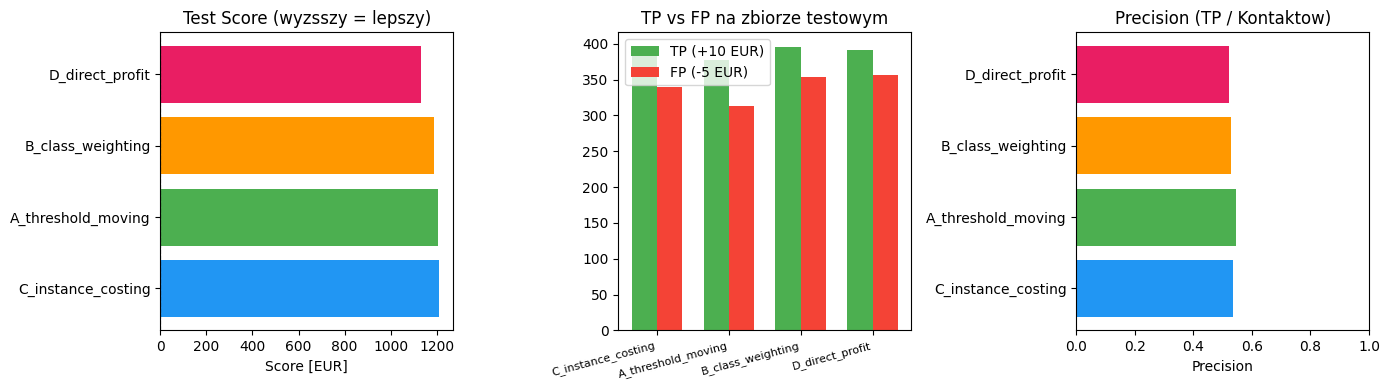

Wykres zapisany jako method_comparison.png


In [25]:
# ── Tabela porownawcza ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_res = pd.DataFrame(results).T.reset_index()
df_res.columns = ['Metoda', 'Val Score', 'Test Score', 'Prog', 'Kontaktow', 'TP', 'FP']
df_res[['Val Score', 'Test Score', 'Prog', 'Kontaktow', 'TP', 'FP']] = \
    df_res[['Val Score', 'Test Score', 'Prog', 'Kontaktow', 'TP', 'FP']].apply(pd.to_numeric)
df_res['Precision'] = (df_res['TP'] / df_res['Kontaktow']).round(3)
df_res = df_res.sort_values('Test Score', ascending=False).reset_index(drop=True)

print("=" * 80)
print(df_res[['Metoda', 'Val Score', 'Test Score', 'Prog', 'Kontaktow', 'TP', 'FP', 'Precision']].to_string(index=False))
print("=" * 80)
print(f"\nNajlepszy Test Score: {df_res.iloc[0]['Test Score']:.1f}  ({df_res.iloc[0]['Metoda']})")

# ── Wykres bar ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
metody = df_res['Metoda'].tolist()

# Test Score
axes[0].barh(metody, df_res['Test Score'], color=colors_bar[:len(metody)])
axes[0].set_title('Test Score (wyzsszy = lepszy)')
axes[0].set_xlabel('Score [EUR]')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# TP vs FP
x = np.arange(len(metody))
width = 0.35
axes[1].bar(x - width/2, df_res['TP'], width, label='TP (+10 EUR)', color='#4CAF50')
axes[1].bar(x + width/2, df_res['FP'], width, label='FP (-5 EUR)',  color='#F44336')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m[:20] for m in metody], rotation=15, ha='right', fontsize=8)
axes[1].set_title('TP vs FP na zbiorze testowym')
axes[1].legend()

# Precision
axes[2].barh(metody, df_res['Precision'], color=colors_bar[:len(metody)])
axes[2].set_title('Precision (TP / Kontaktow)')
axes[2].set_xlabel('Precision')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Wykres zapisany jako method_comparison.png")
